### Implementing simple Chatbot Using LangGraph

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
#Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [4]:
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [5]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [6]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")
llm.invoke("Hello sir, How are you?")

AIMessage(content='Hello! I’m just a computer program, so I don’t have feelings, but I’m here to help you. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 14, 'total_tokens': 45, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-CzuTPliFqj9kSfSV0e2wRK8xfmE3Q', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019bd8ef-645d-74f0-9661-f75938c47776-0', usage_metadata={'input_tokens': 14, 'output_tokens': 31, 'total_tokens': 45, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

### We Will start With Creating Nodes

In [7]:
def SuperChatBot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

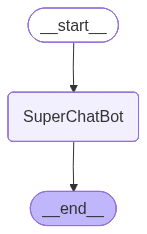

In [8]:
graph=StateGraph(State)

# Add node
graph.add_node("SuperChatBot", SuperChatBot)

# Define edges
graph.add_edge(START, "SuperChatBot")
graph.add_edge("SuperChatBot", END)

graph_builder = graph.compile()

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [9]:
# Invoke

graph_builder.invoke({"messages": ["My name is Aniruddha. Can you tell me a joke?"]})

{'messages': [HumanMessage(content='My name is Aniruddha. Can you tell me a joke?', additional_kwargs={}, response_metadata={}, id='75a3de8a-e195-40a0-b747-77cc5e10c933'),
  AIMessage(content="Sure, Aniruddha! Here's a joke for you:\n\nWhy don't skeletons fight each other?\n\nThey don't have the guts!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 22, 'total_tokens': 49, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-Czua7lnV7O0y1WDfquCnzjMFjVxDE', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019bd8f5-bf53-7413-ba97-b1fa172f4159-0', usage_metadata={'input_tokens': 22, 'output_tokens': 27, 'total_tokens': 49, 

#### Streaming The responses

In [10]:

for events in graph_builder.stream({"messages": ["My name is Aniruddha. Can you tell me a joke?"]}):
    print(events)

{'SuperChatBot': {'messages': [AIMessage(content="Sure, Aniruddha! Here's a joke for you: \n\nWhy don't scientists trust atoms?\n\nBecause they make up everything!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 22, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-Czuc5z4S9ybWC1s4wqVzLtG5ZuitM', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019bd8f7-9eba-75a1-97c9-eb9ea6779acd-0', usage_metadata={'input_tokens': 22, 'output_tokens': 26, 'total_tokens': 48, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}
